In [73]:
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
df = pd.read_csv('../public/data/vambe_clients_10k.csv', encoding='utf-8')

if 'id' not in df.columns:
    df.insert(0, 'id', range(1, len(df) + 1))
    df.to_csv('../public/data/vambe_clients_10k.csv', index=False)
    df = pd.read_csv('../public/data/vambe_clients_10k.csv', encoding='utf-8')

df["Fecha de la Reunion"] = pd.to_datetime(
    df["Fecha de la Reunion"],
    errors="coerce"
)
df.head()

,id,Nombre,Correo Electronico,Numero de Telefono,Fecha de la Reunion,Vendedor asignado,closed,Transcripcion
0,1,Carlos Rodríguez López,carlos.rodriguez@example.com,56912345678,2024-02-15,Toro,1,Somos una cadena de retail con 12 sucursales e...
1,2,María Fernández Gutiérrez,maria.fernandez@example.com,56923456789,2024-03-22,Puma,0,Gestiono una clínica dental con tres sedes en ...
2,3,Roberto Silva Núñez,roberto.silva@example.com,56934567890,2024-04-10,Zorro,1,Dirigimos una plataforma de e-commerce de tecn...
3,4,Patricia González Morales,patricia.gonzalez@example.com,56945678901,2024-05-05,Boa,1,Soy dueña de un restaurante popular en el cent...
4,5,Francisco Torres Espinoza,francisco.torres@example.com,56956789012,2024-06-18,Tiburón,0,Somos una agencia de seguros con oficinas en c...


# General

In [75]:
closed = df[df['closed'] == 1].shape[0]
open = df[df['closed'] == 0].shape[0]
print(f'Cantidad de casos closed: {closed}')
print(f'Cantidad de casos open: {open}')

Cantidad de casos closed: 6888
Cantidad de casos open: 3112


In [76]:
fecha_min = df['Fecha de la Reunion'].min()
fecha_max = df['Fecha de la Reunion'].max()
print(f'Fecha mínima: {fecha_min}')
print(f'Fecha máxima: {fecha_max}')

Fecha mínima: 2024-01-03 00:00:00
Fecha máxima: 2025-03-31 00:00:00


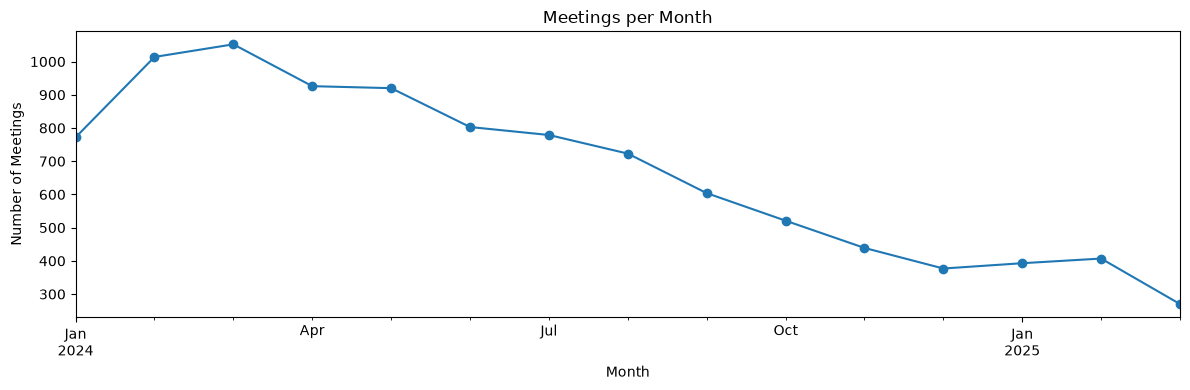

In [77]:
meetings_per_month = (
    df.set_index("Fecha de la Reunion")
      .resample("ME")
      .size()
)

plt.figure(figsize=(12, 4))
meetings_per_month.plot(marker="o")
plt.title("Meetings per Month")
plt.xlabel("Month")
plt.ylabel("Number of Meetings")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribución de reuniones por Vendedor asignado')

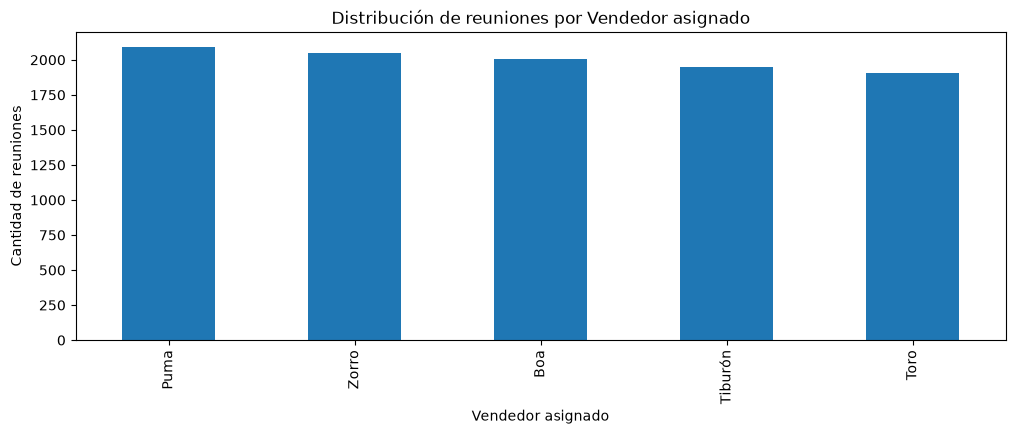

In [78]:
plt.figure(figsize=(12, 4))
df['Vendedor asignado'].value_counts().plot(kind='bar')
plt.xlabel('Vendedor asignado')
plt.ylabel('Cantidad de reuniones')
plt.title('Distribución de reuniones por Vendedor asignado')

# Reuniones clientes

In [79]:
# Are there any clients with more than one meeting? If so, how many?
clients_with_multiple_meetings = df.groupby("Correo Electronico").size()
print(f'Cantidad de clientes con más de una reunión: {clients_with_multiple_meetings[clients_with_multiple_meetings > 1].count()}')
print(f'Clientes con más de una reunión:\n{clients_with_multiple_meetings[clients_with_multiple_meetings > 1]}')

Cantidad de clientes con más de una reunión: 5
Clientes con más de una reunión:
Correo Electronico
c.ramirez2@example.com    2
carevalo2@example.com     2
cnavarro2@example.com     2
mherrera2@example.com     2
mlopez2@example.com       2
dtype: int64


In [80]:
clients_with_multiple_meetings_df = df[df['Correo Electronico'].isin(clients_with_multiple_meetings[clients_with_multiple_meetings > 1].index)]
clients_with_multiple_meetings_df.sort_values(by='Correo Electronico', inplace=True)
clients_with_multiple_meetings_df.head(10)

,id,Nombre,Correo Electronico,Numero de Telefono,Fecha de la Reunion,Vendedor asignado,closed,Transcripcion
6490,6491,Claudia Ramírez Peña,c.ramirez2@example.com,56978901237,2024-02-14,Toro,1,Administro una plataforma de capacitación corp...
9300,9301,Constanza Gloria Ramírez,c.ramirez2@example.com,56987649012,2024-09-01,Boa,0,Soy gerenta de una tienda online de cosméticos...
274,275,Cristina Arévalo Reyes,carevalo2@example.com,56901237891,2024-08-03,Tiburón,1,Tenemos una empresa de decoración de interiore...
5868,5869,Carolina Arévalo Silva,carevalo2@example.com,56985432876,2024-09-02,Puma,1,Dirijo una empresa de catering y eventos con c...
777,778,Catalina Navarro,cnavarro2@example.com,56985567890,2024-12-22,Zorro,1,Gestiono un estudio de yoga y meditación con c...
5851,5852,Cecilia Navarro Molina,cnavarro2@example.com,56981357924,2024-04-12,Tiburón,1,Somos una clínica veterinaria con 2 sucursales...
275,276,Miguel Herrera Castillo,mherrera2@example.com,56912348902,2024-07-18,Toro,1,Operamos una empresa de telecomunicaciones que...
2972,2973,Martin Herrera Diaz,mherrera2@example.com,56965567890,2024-08-12,Puma,1,Administro una empresa de instalacion de panel...
284,285,Miriam López Núñez,mlopez2@example.com,56901238902,2024-07-13,Tiburón,0,Gestiono una empresa de exportación de vinos c...
1207,1208,Marta López Ibáñez,mlopez2@example.com,56983456780,2024-09-12,Boa,1,Administro un colegio privado con 600 alumnos ...


Se concluye que los casos son errores y no corresponden a reuniones del mismo cliente. Por lo tanto, se procesaran como casos individuales.

In [83]:
with pd.option_context("display.max_colwidth", None):
    display(df[["Transcripcion", "closed"]].sample(20))

,Transcripcion,closed
3431,"Somos una empresa de consultoria ambiental que atiende proyectos de minería, energía y construcción. Empresas consultan sobre servicios de diagnóstico ambiental, permisos ambientales, mitigación de impacto y cumplimiento normativo. Procesamos aproximadamente 50 consultas mensuales. Encontré Vambe en LinkedIn mediante contenido relacionado a transformación digital en sustentabilidad. Buscamos un chatbot que describa servicios de diagnóstico, responda preguntas sobre normativa ambiental chilena, informe sobre tiempos de permisos, y agende consultas técnicas. El bot debe ser especializado técnicamente, integrable con nuestro CRM de grandes empresas mineras, y capaz de derivar proyectos complejos a consultores senior.",1
4190,"Soy dueño de una cadena de 6 restaurantes en distintos puntos de Santiago especializados en cocina fusión. Recibimos alrededor de 500 llamadas y mensajes diarios con consultas sobre reservas, horarios, menú, alergias e ingredientes especiales. El sistema actual es caótico. Encontré Vambe a través de Google cuando buscaba soluciones de automatización para restaurantes. Necesito que el chatbot confirme y gestione reservas automáticamente, que responda sobre nuestro menú con detalle nutricional, que sea capaz de registrar restricciones dietéticas, y que maneje bien cambios de horario. El tono debe ser cálido e invitador.",1
3660,"Somos una empresa de consultoría empresarial que asesora en transformación digital y optimización de procesos. Clientes potenciales nos contactan para conocer servicios, solicitar propuestas personalizadas y consultar sobre experiencia en su industria. Procesamos alrededor de 55 consultas por semana. Encontré Vambe en LinkedIn en un artículo sobre automatización de ventas. Buscamos que el chatbot califique leads según industria y tamaño empresa, que responda preguntas sobre metodología y que agende demostraciones de forma automática con nuestro equipo comercial.",1
242,"Gestiono un colegio privado con 800 alumnos en Las Condes. Los apoderados escriben constantemente consultando sobre calificaciones, actividades escolares, horarios, aranceles y eventos. Recibimos aproximadamente 300 mensajes diarios vía portal y WhatsApp. Conocí Vambe a través de un artículo en una revista de educación. Necesito un chatbot que acceda al sistema académico, muestre avances por estudiante, informe sobre próximas evaluaciones y actividades extracurriculares. También debe poder responder sobre aranceles, becas y políticas de disciplina sin revelar datos de otros estudiantes.",0
3540,"Administro un hotel boutique en San Pedro de Atacama con 30 habitaciones. Recibimos alrededor de 100 consultas mensuales sobre disponibilidad, tarifas, actividades turísticas, reservas y políticas de cancelación. Los turistas a menudo escriben desde diferentes zonas horarias. Encontré Vambe en un podcast sobre turismo y tecnología. La idea de un chatbot multiidioma que maneje reservas en tiempo real suena atractiva, pero me preocupa cómo manejaría cambios de tarifas dinámicas según temporada.",0
1030,"Operamos una cadena de farmacias con 15 sucursales. Manejamos cerca de 800 consultas diarias sobre disponibilidad de medicamentos, efectos secundarios, recomendaciones y envíos a domicilio. Nos enteramos de Vambe a través de Google cuando buscábamos soluciones de automatización para salud. Lo crucial es que el chatbot tenga datos farmacéuticos precisos, respete regulaciones sobre información médica y logre derivar consultas que requieran asesor real con médico o farmacéutico.",0
5608,"Trabajo en una empresa de servicios de limpieza comercial. Tenemos aproximadamente 350 clientes y recibimos alrededor de 200 solicitudes mensuales de nuevos prospectos pidiendo presupuesto, consultando servicios disponibles y planificando visitas. Me enteré de Vambe a través de un evento de networking de empresas de servicios. Necesitamos un chatbot que tome solicitudes de presupuesto, clasifique los tipos de limpieza reque

## Descubrimientos / Patrones

### Categorías

#### Categoría 1: Información de la empresa
- Área/Industria de la empresa (Salud, Energía, Educación, etc.)
- Sector (B2B, B2C, B2B2C, etc.)
- Tamaño de la empresa
- Volumen de consultas al mes
- Quién habla (CEO, CTO, CMO, etc.)
- Cómo se enteró de vambe (referido, linkedin, etc.)

#### Categoría 2: Información de la solución
- Canales (whatsapp, messenger, webchat, etc.)
- Casos de uso principales (agendamiento, seguimiento, etc.)
- Requerimientos (multiidioma, integrarse con ..., tener un tono o personalidad, )
- Requiere integraciones con otros sistemas?
- Tono deseado (personalidad del chatbot)

#### Categoría 3: 
- Complejidad técnica (que tan complejo es el caso de uso)
- Urgencia / 
- Menciona competencia
- Sentimiento del cliente (positivo, negativo, neutral)

"perfil_cliente": {
      "industria": "string - Sector económico normalizado. Usa el nombre exacto que menciona el cliente. Ejemplos conocidos: Restaurantes, Inmobiliaria, Educacion, Salud, Turismo, Manufactura, Software, Servicios, Consultoria, Ecommerce, Publicidad. Si menciona algo nuevo, úsalo tal cual.",
      "sector_b2b_b2c": "enum: B2B | B2C | B2B2C | no_inferible",
      "tamano_empresa": "enum: Pequeña | Mediana | Grande | no_inferible",
      "decisor_identificado": "string | 'no_mencionado' - Rol de quien habla. Inferir del contexto. Si no se puede → 'no_mencionado'"
      "volumen_consultas_mensual": "number | null - Estimación mensual. Si dice '500 diarias' → 15000. Si dice '55 semanales' → 220. Si no hay dato → null",
      "canal_descubrimiento": "string - Canal específico mencionado. Ejemplos: LinkedIn, Google, Instagram, Evento de networking, Podcast, Revista, Recomendación de colega, Mailing, Banner publicitario, Grupo de WhatsApp. Si no se menciona → 'no_mencionado'",
      "tipo_canal": "enum: Busqueda Organica | Organico Social | Offline/Evento | Referido | Publicidad Display | Publicidad PPC | Email | Podcast | Revista/Editorial | Otro | no_mencionado"
    },
    "necesidades_y_casos_uso": {
      "area_negocio_principal": "enum: Ecommerce | Agendamiento | Venta Consultiva | Atencion al Cliente | Otro | no_inferible - ¿Cuál de las áreas de Vambe encaja mejor? Si no encaja claramente, usa 'Otro' y describe en detalle.",
      "area_negocio_detalle": "string | null - Si area_negocio_principal es 'Otro', describe qué área de negocio representa este cliente. Si no es 'Otro', usa null.",
      "canales_deseados": "['WhatsApp', 'Instagram', 'Facebook', 'TikTok', 'WeChat', 'Web', 'Llamadas', 'Email'] | ['no_mencionado'] - Canales que el cliente quiere usar para su asistente. Extrae SOLO los mencionados. Si menciona uno que Vambe NO soporta (ej: Telegram, Slack), inclúyelo igual. Si no menciona canales → ['no_mencionado']",
      "canales_deseados_no_soportados": "[string] | [] - Lista de canales mencionados que Vambe NO soporta actualmente. Si todos los mencionados están soportados → []",
      "casos_uso_principales": "[string] - Lista de funcionalidades/casos de uso que el cliente menciona. Usa los tags conocidos cuando apliquen: 'agendamiento', 'catalogo_productos', 'cotizacion', 'reservas', 'atencion_cliente', 'calificacion_leads', 'seguimiento_ventas', 'procesamiento_pagos', 'llamadas_ia', 'crm_integracion', 'recomendaciones', 'recordatorios', 'objeciones', 'upsell', 'postventa'. Si menciona algo NUEVO no en esta lista, agrégalo como string directamente. Nunca ignores una funcionalidad mencionada.",
      "casos_uso_nuevos": "[string] | [] - Casos de uso que NO están en la lista predefinida. Esto ayuda al equipo de producto a descubrir demanda nueva. Si todos los casos de uso están en la lista predefinida → []",
      "integraciones_requeridas": "[string] | ['no_mencionado'] - Integraciones específicas mencionadas. Tags conocidos: 'CRM', 'Sistema_academico', 'ERP', 'Calendario', 'Ecommerce'. Si menciona una NO en esta lista (ej: 'SAP', 'Salesforce', 'mi sistema de nómina'), inclúyela como string. Si no menciona → ['no_mencionado']",
    },
    "intencion_compra": {
      "dolor_explicito": "boolean - ¿Menciona explícitamente un problema grave, caótico, insostenible o crisis? Ejemplos: 'sistema caótico', 'no damos abasto', 'colapsado', 'mayor desafío es'. NO incluyas problemas leves o genéricos.",
      "urgencia": "enum: Alta | Media | Baja | no_inferible - ¿Qué tan presionado está el cliente para resolver? Alta = crisis inminente o volumen insostenible. Media = necesidad clara pero manejable. Baja = exploratorio o curioso.",
      "nivel_motivacion": "enum: Critico | Alto | Medio | Bajo | no_inferible - Sinergia de dolor + urgencia + volumen. Critico = dolor explícito + alta urgencia. Alto = necesidad clara + volumen justificable. Medio = interesado pero sin presión. Bajo = exploratorio.",
      "complejidad_tecnica": "enum: Baja | Media | Alta | no_inferible - ¿Qué tan compleja es la solución que pide? Baja = chatbot informativo simple. Media = agendamiento + catálogo + integraciones estándar. Alta = integraciones custom, regulaciones médicas/legales, lógica de negocio compleja.",
      "objeciones_principales": "[string] | [] - Preocupaciones, barreras o dudas explícitas mencionadas. Captura TODAS, incluso las nuevas. Ejemplos conocidos: 'tarifas dinámicas', 'regulaciones médicas', 'privacidad de datos', 'costo'. Si no hay → []",
      "tono_deseado": "string | 'no_mencionado' - Personalidad que espera del asistente. Si no menciona → 'no_mencionado'"
    },
    "afinidad_vambe": {
    "vambe_readiness_score": "number 0-100 - Score de afinidad con Vambe. Calcula así:
      +25 pts: Volumen de consultas justifica inversión (>200/mes o >10/día)
      +20 pts: Necesita agendamiento, reservas o catálogo (core de Vambe)
      +15 pts: Necesita calificación de leads o seguimiento de ventas
      +10 pts: Canal de descubrimiento = Offline/Evento o Referido (alta conversión)
      +10 pts: Dolor explícito presente (motivación de compra fuerte)
      +10 pts: Complejidad técnica = Baja o Media (implementable en 1 mes)
      +10 pts: Canales deseados incluyen WhatsApp/Instagram/Web (soportados nativamente)
      -20 pts: Requiere regulaciones médicas/farmacéuticas/legales complejas (fuera de scope)
      -15 pts: Complejidad Alta + integraciones custom exóticas (riesgo de proyecto)
      -10 pts: Necesita ERP completo o sistema de gestión académica total (no es chatbot)
      -10 pts: Volumen muy bajo (<20/mes) o negocio muy pequeño
      Mínimo 0, máximo 100. Redondea a entero.",
    "razon_bajo_readiness": "string | null - SI Y SOLO SI vambe_readiness_score < 50. Resume en 1-2 oraciones por qué este cliente tiene bajo readiness. Enfócate en:
      1. ¿Qué funcionalidad necesita que Vambe NO tiene?
      2. ¿Qué barrera (regulatoria, técnica, de volumen) lo hace difícil?
      3. ¿Qué tendría que cambiar Vambe para que este caso sea viable?
      Ejemplo: 'Necesita ERP académico completo con privacidad de datos estudiantiles. Vambe no es un sistema de gestión escolar. Oportunidad: módulo educativo o integración con LMS.'
      Si score >= 50 → null",
  }

{
  "system": "Eres un analista de ventas experto. Extrae información estructurada de transcripciones de reuniones de ventas de Vambe AI (chatbots inteligentes).",
  "output_format": {
    "dolor_explicito": "boolean - ¿menciona problema urgente/caótico?",
    "presupuesto_implicito": "enum: Bajo | Medio | Alto",
    "objeciones_principales": ["lista de strings o vacío"],
    "sentimiento_general": "enum: Positivo | Neutral | Preocupado | Escéptico",
    "madurez_digital": "enum: Baja | Media | Alta"
  }
}